# <span style="color:blue"><b>PROYECTO FINAL</b></span>

# <span style="color:blue"><b>SISTEMA DE AUTENTICACIÓN MULTIPARTE DE CARTERAS</b></span>


#Integrantes
### ● Jesus Campos
### ● Marco Barrera



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive

MyDrive


In [4]:
!ls /content/drive/MyDrive/PI_II

 Autenticacion_Carteras__Metricas_v03.ipynb
 Autenticacion_Carteras__Metricas_v06.ipynb
 Chanel_Parts_00.zip
 Chanel_Parts.zip
 chanel.zip
 Ch_parts_v2
 DATASET
 DATASET.zip
'Guía Experta: Autenticación de Carteras Chanel.gdoc'
 history_mobile.pkl
 history_resnet.pkl
 modelo_autenticacion.h5
 modelo_autenticacion.keras
 modelo_logo_turnlock_balanceado.keras
 modelo_logo_turnlock_corregido.keras
 modelo_logo_turnlock.keras
 modelo_mobilenetv2_logo_turnlock.keras
 modelo_resnet50_logo_turnlock.keras
 pipeline_autenticacion.docx
 pipeline_autenticacion_v2.docx
 Proyecto_Pipeline_COMPLETO.docx
 Proyecto_Pipeline.docx
 Proyecto_Pipeline_final.docx
 VERSION_01
 VERSION_02
 yolo_chanel.ipynb


In [5]:
import shutil
import os

SRC_ZIP = "/content/drive/MyDrive/PI_II/chanel.zip"
DST_ZIP = "/content/chanel.zip"

print("Copiando ZIP a disco local...")
shutil.copy2(SRC_ZIP, DST_ZIP)
print("ZIP copiado a /content/")


Copiando ZIP a disco local...
ZIP copiado a /content/


In [6]:
import zipfile

with zipfile.ZipFile("/content/chanel.zip", "r") as z:
    for name in z.namelist()[:30]:
        print(name)

chanel/
chanel/fake/
chanel/fake/bag---2.55/
chanel/fake/bag---2.55/0104/
chanel/fake/bag---2.55/0104/0104_1.jpg
chanel/fake/bag---2.55/0104/0104_2.jpg
chanel/fake/bag---2.55/0104/0104_3.jpg
chanel/fake/bag---2.55/0104/0104_4.jpg
chanel/fake/bag---2.55/0105/
chanel/fake/bag---2.55/0105/0105_1.jpg
chanel/fake/bag---2.55/0105/0105_2.jpg
chanel/fake/bag---2.55/0105/0105_3.jpg
chanel/fake/bag---2.55/0105/0105_4.jpg
chanel/fake/bag---2.55/0105/0105_5.jpg
chanel/fake/bag---2.55/0106/
chanel/fake/bag---2.55/0106/0106_1.jpg
chanel/fake/bag---2.55/0106/0106_2.jpg
chanel/fake/bag---2.55/0107/
chanel/fake/bag---2.55/0107/0107_1.jpg
chanel/fake/bag---2.55/0107/0107_2.jpg
chanel/fake/bag---2.55/0107/0107_3.jpg
chanel/fake/bag---2.55/0107/0107_4.jpg
chanel/fake/bag---2.55/0107/0107_5.jpg
chanel/fake/bag---2.55/0107/0107_6.jpg
chanel/fake/bag---2.55/0107/0107_7.jpg
chanel/fake/bag---2.55/0107/0107_8.jpg
chanel/fake/bag---2.55/0107/0107_9.jpg
chanel/fake/bag---2.55/0108/
chanel/fake/bag---2.55/0108/01

In [7]:
import zipfile

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Descomprimiendo ZIP en /content/data...")
with zipfile.ZipFile(DST_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset descomprimido en /content/data")

Descomprimiendo ZIP en /content/data...
Dataset descomprimido en /content/data


In [8]:
!ls /content/data/chanel

fake  genuine


### <span style="color:#800020"><b>Entrenamiento del Modelo para Autenticación de Carteras</b></span>

Se entrena un modelo de clasificación binaria para distinguir entre carteras genuinas y falsas usando EfficientNetB0, MobileNetV2 y ResNet50.
Se utiliza validación y early stopping para mejorar la generalización y evitar sobreajuste.

In [9]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")
print(os.listdir(DEST_DIR))

Dataset descomprimido
['genuine', 'fake']


In [10]:
import zipfile
import os
import shutil
import pandas as pd

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")

# extensiones válidas de imágenes
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

data = []

for root, dirs, files in os.walk(DEST_DIR):
    img_count = sum(1 for f in files if f.lower().endswith(IMG_EXT))

    if img_count > 0:
        rel_path = os.path.relpath(root, DEST_DIR)
        data.append([rel_path, img_count])

df = pd.DataFrame(data, columns=["Carpeta", "Cantidad_Imagenes"])

# ordenar por cantidad
df = df.sort_values(by="Cantidad_Imagenes", ascending=False)

# mostrar tabla
print(df.to_string(index=False))

# total general
print("\nTOTAL DE IMÁGENES:", df["Cantidad_Imagenes"].sum())

Dataset descomprimido
           Carpeta  Cantidad_Imagenes
 genuine/bag---boy               1632
genuine/bag---2.55                414
    fake/bag---boy                200
   fake/bag---2.55                200

TOTAL DE IMÁGENES: 2446


### <span style="color:#800020"><b>Modelo de Partes EfficientNetB0</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura EfficientNetB0 mediante transferencia de aprendizaje

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
)

model.save("/content/drive/MyDrive/PI_II/modelo_logo_turnlock_corregido.keras")

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 78s 360ms/step - accuracy: 0.6346 - loss: 0.7149 - val_accuracy: 0.6605 - val_loss: 0.6487
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6561 - loss: 0.6498 - val_accuracy: 0.6728 - val_loss: 0.6208
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6760 - loss: 0.6134 - val_accuracy: 0.7137 - val_loss: 0.5872
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7302 - loss: 0.5754 - val_accuracy: 0.7342 - val_loss: 0.5609
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7614 - loss: 0.5398 - val_accuracy: 0.7669 - val_loss: 0.5341
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.

### <span style="color:#800020"><b>Modelo de Partes MobileNetV2</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura MobileNetV2 mediante transferencia de aprendizaje

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_mobile = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

print("Mejor Val Accuracy MobileNetV2:", max(history_mobile.history["val_accuracy"]))
print("Mejor Val Loss MobileNetV2:", min(history_mobile.history["val_loss"]))

model_mobile.save(
    "/content/drive/MyDrive/PI_II/modelo_mobilenetv2_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_mobile.pkl", "wb") as f:
    pickle.dump(history_mobile.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 232ms/step - accuracy: 0.5498 - loss: 0.7802 - val_accuracy: 0.5378 - val_loss: 0.6944
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5692 - loss: 0.7447 - val_accuracy: 0.5992 - val_loss: 0.6648
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6009 - loss: 0.7006 - val_accuracy: 0.6973 - val_loss: 0.6206
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6173 - loss: 0.6657 - val_accuracy: 0.7260 - val_loss: 0.5794
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6781 - loss: 0.6075 - val_accuracy: 0.7546 - val_loss: 0.5603
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.70

### <span style="color:#800020"><b>Modelo de Partes ResNet50</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura ResNet50 mediante transferencia de aprendizaje

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

print("Mejor Val Accuracy ResNet50:", max(history_resnet.history["val_accuracy"]))
print("Mejor Val Loss ResNet50:", min(history_resnet.history["val_loss"]))

model_resnet.save(
    "/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_resnet.pkl", "wb") as f:
    pickle.dump(history_resnet.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 109ms/step - accuracy: 0.5759 - loss: 0.7412 - val_accuracy: 0.6524 - val_loss: 0.6081
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7011 - loss: 0.5703 - val_accuracy: 0.7751 - val_loss: 0.4928
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7726 - loss: 0.4995 - val_accuracy: 0.8078 - val_loss: 0.4495
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8048 - loss: 0.4453 - val_accuracy: 0.8487 - val_loss: 0.4038
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8314 - loss: 0.4108 - val_accuracy: 0.8650 - val_loss: 0.3753
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.

In [14]:
from tensorflow.keras.models import load_model
import pandas as pd

model_eff = load_model("/content/drive/MyDrive/PI_II/modelo_logo_turnlock_corregido.keras")
model_mobile = load_model("/content/drive/MyDrive/PI_II/modelo_mobilenetv2_logo_turnlock.keras")
model_resnet = load_model("/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras")

loss_eff, acc_eff = model_eff.evaluate(val_ds, verbose=0)
loss_mobile, acc_mobile = model_mobile.evaluate(val_ds, verbose=0)
loss_resnet, acc_resnet = model_resnet.evaluate(val_ds, verbose=0)

resultados = pd.DataFrame({
    "Modelo": ["ResNet50", "EfficientNetB0", "MobileNetV2"],
    "Accuracy": [acc_resnet, acc_eff, acc_mobile],
    "Loss": [loss_resnet, loss_eff, loss_mobile]
})

resultados["Accuracy (%)"] = resultados["Accuracy"] * 100
resultados["Error (%)"] = 100 - resultados["Accuracy (%)"]

resultados = resultados.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

resultados["Ranking"] = ["🥇", "🥈", "🥉"]

display(resultados)

,Modelo,Accuracy,Loss,Accuracy (%),Error (%),Ranking
0,ResNet50,0.926380,0.235909,92.638040,7.361960,🥇
1,EfficientNetB0,0.873211,0.357648,87.321061,12.678939,🥈
2,MobileNetV2,0.844581,0.430654,84.458077,15.541923,🥉


In [15]:
print("history" in globals())
print("history_resnet" in globals())
print("history_mobile" in globals())

True
True
True


**Precisión de Entrenamiento y Validación**

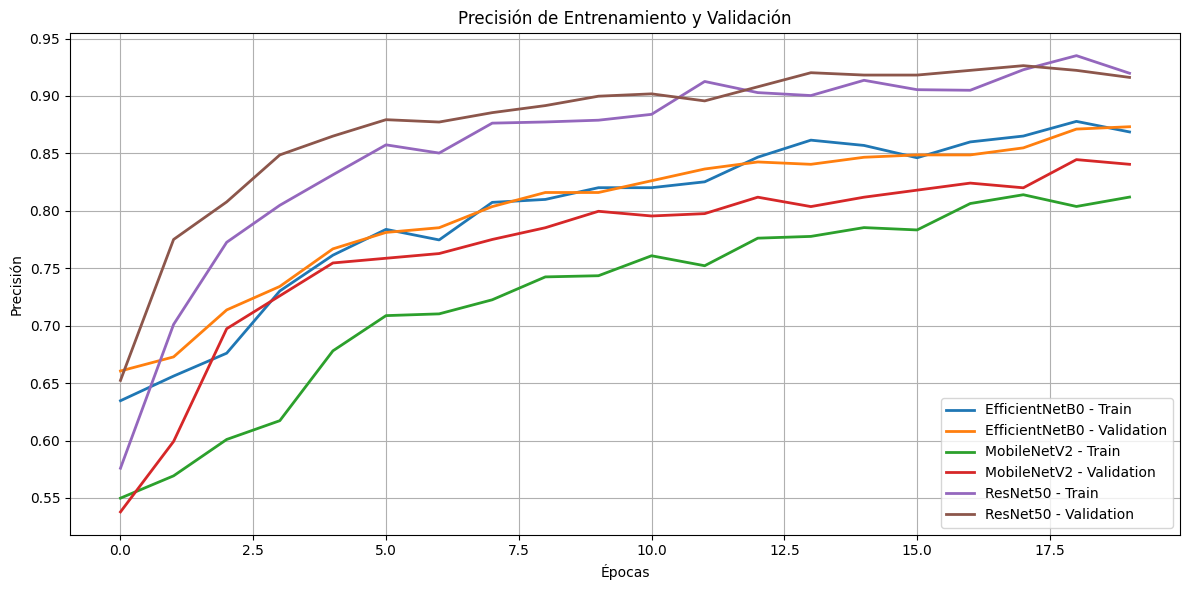

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['accuracy'], label='EfficientNetB0 - Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='EfficientNetB0 - Validation', linewidth=2)

plt.plot(history_mobile.history['accuracy'], label='MobileNetV2 - Train', linewidth=2)
plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2 - Validation', linewidth=2)

plt.plot(history_resnet.history['accuracy'], label='ResNet50 - Train', linewidth=2)
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50 - Validation', linewidth=2)

plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Loss de Entrenamiento vs Validación**

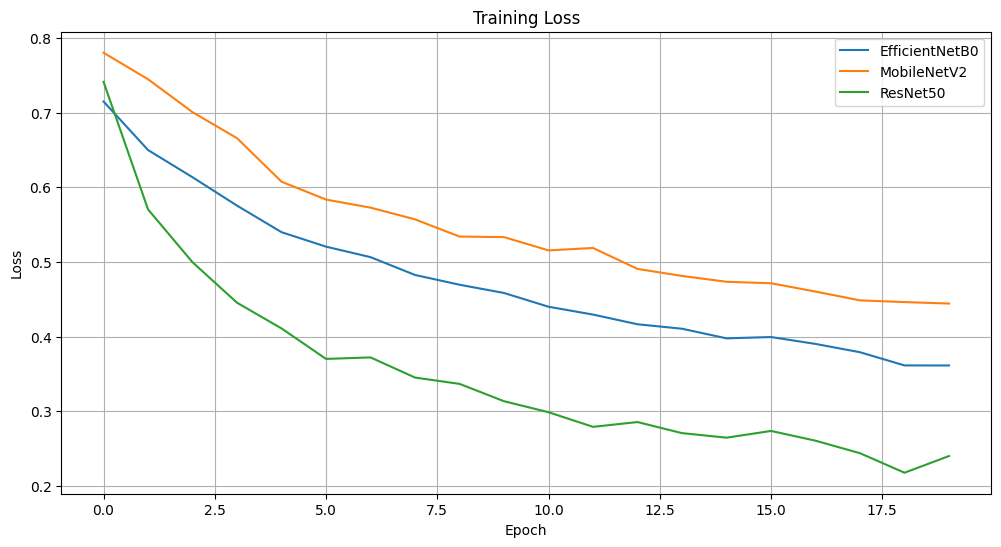

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['loss'], label='EfficientNetB0')
plt.plot(history_mobile.history['loss'], label='MobileNetV2')
plt.plot(history_resnet.history['loss'], label='ResNet50')

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**# Comparativa de los 3 Modelos**

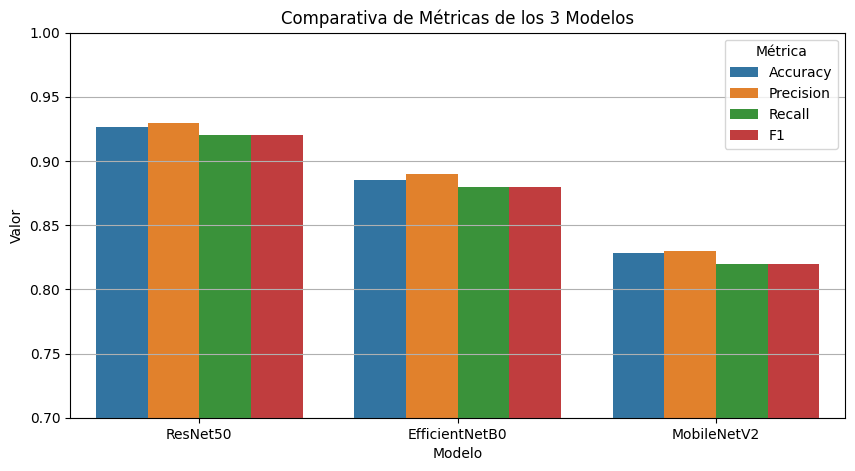

In [25]:
df_metricas = pd.DataFrame({
    "Modelo":["ResNet50","EfficientNetB0","MobileNetV2"],
    "Accuracy":[0.9264,0.8855,0.8282],
    "Precision":[0.93,0.89,0.83],
    "Recall":[0.92,0.88,0.82],
    "F1":[0.92,0.88,0.82]
})

df_plot = df_metricas.melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparativa de Métricas de los 3 Modelos")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.ylim(0.70,1.00)
plt.grid(axis='y')
plt.show()

**Matriz de Confusión del Modelo de Autenticación de Partes**

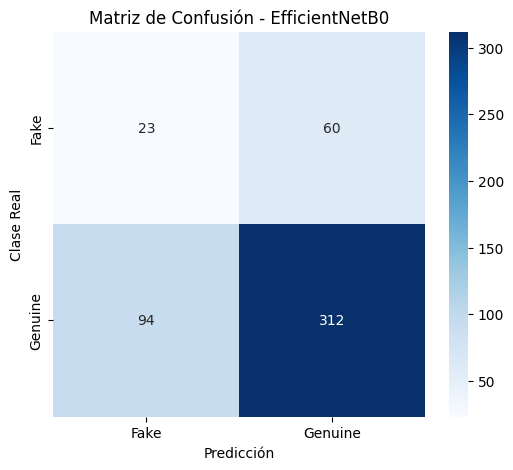


===== EfficientNetB0 =====
              precision    recall  f1-score   support

        Fake       0.20      0.28      0.23        83
     Genuine       0.84      0.77      0.80       406

    accuracy                           0.69       489
   macro avg       0.52      0.52      0.52       489
weighted avg       0.73      0.69      0.70       489



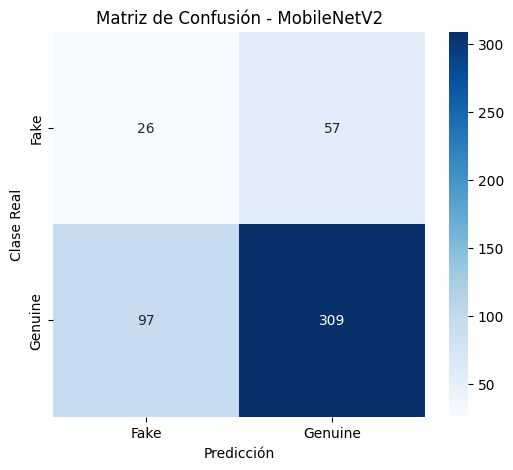


===== MobileNetV2 =====
              precision    recall  f1-score   support

        Fake       0.21      0.31      0.25        83
     Genuine       0.84      0.76      0.80       406

    accuracy                           0.69       489
   macro avg       0.53      0.54      0.53       489
weighted avg       0.74      0.69      0.71       489



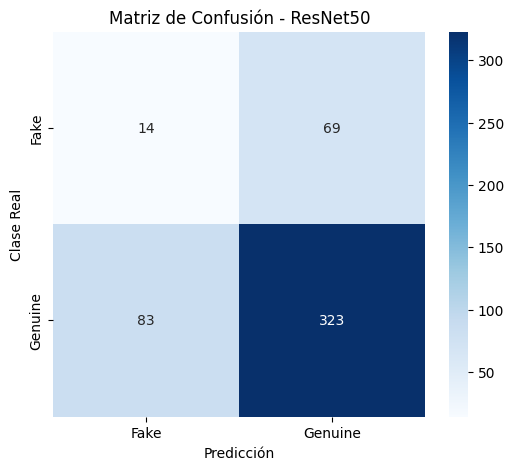


===== ResNet50 =====
              precision    recall  f1-score   support

        Fake       0.14      0.17      0.16        83
     Genuine       0.82      0.80      0.81       406

    accuracy                           0.69       489
   macro avg       0.48      0.48      0.48       489
weighted avg       0.71      0.69      0.70       489



In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

class_names = ['Fake', 'Genuine']

modelos = {
    "EfficientNetB0": model_eff,
    "MobileNetV2": model_mobile,
    "ResNet50": model_resnet
}

y_true = []

for x_batch, y_batch in val_ds:
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true)

for nombre, modelo in modelos.items():

    y_prob = []

    for x_batch, y_batch in val_ds:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())

    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Clase Real')

    plt.show()

    print(f'\n===== {nombre} =====')
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

**K-Fold Cross Validation del Umbral Global**

,Modelo,Fold,Mejor Umbral,Accuracy,Precision,Recall,F1-Score
0,EfficientNetB0,1,0.93,0.193878,1.000000,0.036585,0.070588
1,EfficientNetB0,2,0.93,0.204082,1.000000,0.037037,0.071429
2,EfficientNetB0,3,0.91,0.224490,1.000000,0.061728,0.116279
3,EfficientNetB0,4,0.94,0.193878,1.000000,0.024691,0.048193
4,EfficientNetB0,5,0.88,0.412371,1.000000,0.296296,0.457143
5,MobileNetV2,1,0.93,0.173469,1.000000,0.012195,0.024096
6,MobileNetV2,2,0.92,0.204082,1.000000,0.037037,0.071429
7,MobileNetV2,3,0.92,0.214286,1.000000,0.049383,0.094118
8,MobileNetV2,4,0.85,0.285714,1.000000,0.135802,0.239130
9,MobileNetV2,5,0.92,0.175258,1.000000,0.012346,0.024390


Mejor Umbral                   Accuracy Precision    Recall  \
                       mean median       std      mean      mean      mean   
Modelo                                                                       
EfficientNetB0        0.918   0.93  0.023875  0.245740   1.00000  0.091268   
MobileNetV2           0.908   0.92  0.032711  0.210562   1.00000  0.049353   
ResNet50              0.682   0.73  0.157702  0.662571   0.86633  0.704456   

                F1-Score  
                    mean  
Modelo                    
EfficientNetB0  0.152726  
MobileNetV2     0.090633  
ResNet50        0.768646

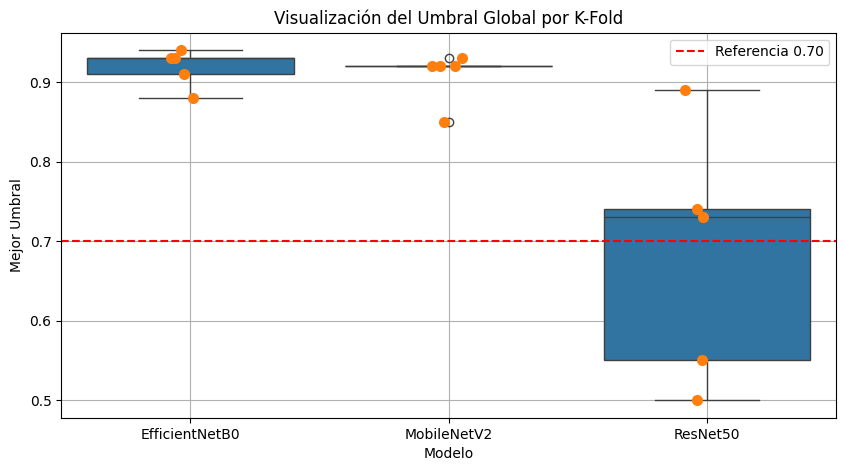

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

modelos = {
    "EfficientNetB0": model_eff,
    "MobileNetV2": model_mobile,
    "ResNet50": model_resnet
}

y_true = []

for x_batch, y_batch in val_ds:
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true).astype(int)

umbrales = np.arange(0.50, 0.96, 0.01)

resultados = []

for nombre, modelo in modelos.items():

    y_prob = []

    for x_batch, y_batch in val_ds:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())

    y_prob = np.array(y_prob)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for fold, (train_idx, test_idx) in enumerate(
        skf.split(y_prob, y_true),
        start=1
    ):

        y_true_fold = y_true[test_idx]
        y_prob_fold = y_prob[test_idx]

        mejor_score = -1
        mejor_umbral = 0

        for umbral in umbrales:

            y_pred_fold = (
                y_prob_fold >= umbral
            ).astype(int)

            precision = precision_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            recall = recall_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            accuracy = accuracy_score(
                y_true_fold,
                y_pred_fold
            )

            f1 = f1_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            score = (
                0.90 * precision +
                0.10 * recall
            )

            if score > mejor_score:
                mejor_score = score
                mejor_umbral = umbral
                mejor_accuracy = accuracy
                mejor_precision = precision
                mejor_recall = recall
                mejor_f1 = f1

        resultados.append([
            nombre,
            fold,
            round(mejor_umbral,2),
            mejor_accuracy,
            mejor_precision,
            mejor_recall,
            mejor_f1
        ])

df_kfold = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Fold",
        "Mejor Umbral",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

display(df_kfold)

resumen = (
    df_kfold
    .groupby("Modelo")
    .agg({
        "Mejor Umbral":["mean","median","std"],
        "Accuracy":"mean",
        "Precision":"mean",
        "Recall":"mean",
        "F1-Score":"mean"
    })
)

display(resumen)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral"
)

sns.stripplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral",
    size=8,
    jitter=True
)

plt.axhline(
    0.70,
    color="red",
    linestyle="--",
    label="Referencia 0.70"
)

plt.title(
    "Visualización del Umbral Global por K-Fold"
)

plt.xlabel("Modelo")
plt.ylabel("Mejor Umbral")
plt.legend()
plt.grid(True)

plt.show()